# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

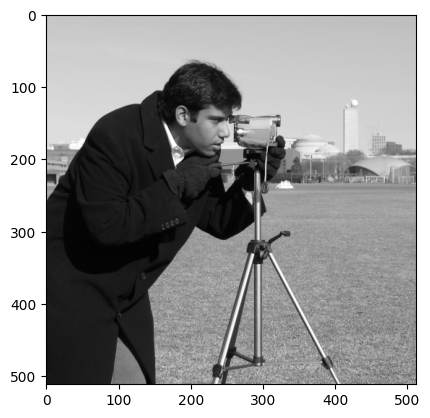

In [9]:
# ── Load image ────────────────────────────────────
image_array = data.camera()
img = Image.fromarray(image_array)
plt.imshow(image_array, cmap='gray')

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [12]:
# Get the size of the image
width, height = img.size
# scaling factors
scale_x = 2
scale_y = 2

In [14]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = width * scale_x
new_height =height* scale_y
# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)


In [16]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [17]:
cx = 2
cy = 1

In [18]:
new_width = width * cx
new_height = height * cy

In [19]:
non_uniform_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [21]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")

### 3. Shear

In [22]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [23]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = (1, shear_factor, 0, 0, 1, 0)

In [24]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_img = img.transform(
    (width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)


In [25]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [31]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array
negative_img = Image.fromarray(negative_array)


In [32]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_pil = ImageOps.invert(img)

In [33]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Apply the log transformation to each pixel
img_array = np.array(img, dtype=np.float32)
c = 255 / np.log(1 + 255)
log_array = c * np.log(1 + img_array)
log_array = np.uint8(log_array)
log_img = Image.fromarray(log_array)

In [34]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
img_array = np.array(img, dtype=np.float32) / 255.0
gamma_array = 255 * (img_array ** gamma)
gamma_array = np.uint8(gamma_array)
gamma_img = Image.fromarray(gamma_array)

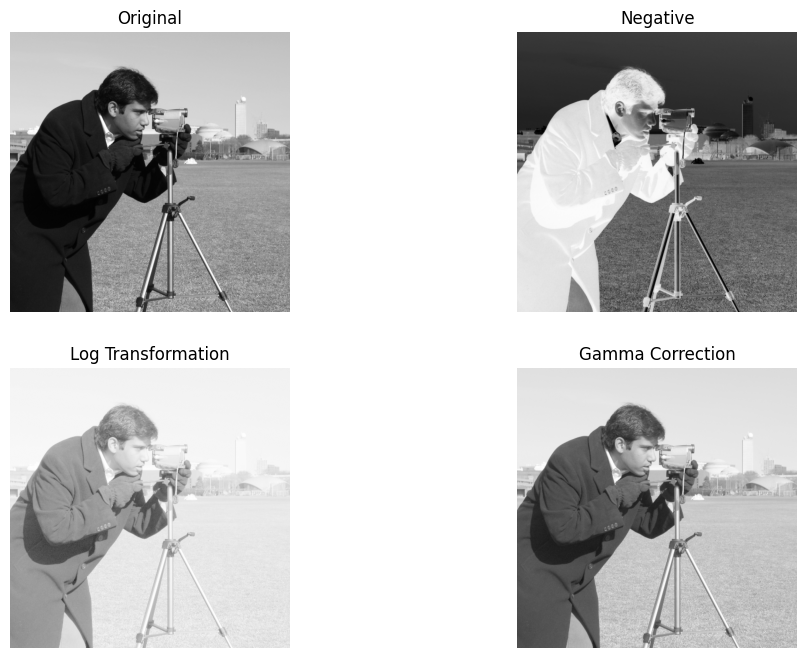

In [36]:
#to show the result of the pre codes

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(negative_img, cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(log_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gamma_img, cmap='gray')
plt.title("Gamma Correction")
plt.axis('off')

plt.show()